In [27]:
import torch
import torch.nn as nn
import torch.optim as optim

class PiecewiseLinearNN(nn.Module):
    """We initialize the neural network, and perform the forward pass to build O_i and add them to f(x_1)
    """
    def __init__(self, num_segments, a, b, f):
        super(PiecewiseLinearNN, self).__init__()
        self.num_segments = num_segments
        self.a = a
        self.b = b
        self.f = f  # Store the function f
        
        # Initialize x_i as trainable parameters
        self.x_i = nn.Parameter(torch.linspace(a, b, num_segments + 1))

    def forward(self, x):
        x = x.unsqueeze(1)  # Ensure x has the correct shape
        predicted_g = torch.zeros_like(x)

        for i in range(self.num_segments):
            x_i = self.x_i[i]
            x_next = self.x_i[i + 1] if i < self.num_segments - 1 else self.b

            k_i = (self.f(x_next) - self.f(x_i)) / (x_next - x_i)
            relu_x_i = torch.relu(x - x_i)
            relu_x_next = torch.relu(x - x_next)

            O_i = torch.sign(k_i) * torch.relu(torch.abs(k_i) * (relu_x_i - relu_x_next))
            predicted_g += O_i

        return predicted_g.squeeze()

def sup_norm_loss(predicted_g, x, model):
    f_values = model.f(x)
    return torch.max(torch.abs(predicted_g - f_values))

# Define the target function f
def f(x):
    # Ensure x is a numpy array, detach if necessary
    return x**3 + 2*x**2 + x

# Model and Training Setup
a = 0
b = 20
num_segments = 20
x_values = torch.linspace(a, b, 100)  # Sample points for training

# Instantiate the model
model = PiecewiseLinearNN(num_segments, a, b, f)

# Define the optimizer
optimizer = optim.SGD([model.x_i], lr=0.01)

# Training loop
num_epochs = 1000
for epoch in range(num_epochs):
    optimizer.zero_grad()  # Clear the gradients
    predicted_g = model(x_values)  # Forward pass
    loss = sup_norm_loss(predicted_g, x_values, model)  # Compute loss
    loss.backward()  # Backpropagation
    optimizer.step()  # Update x_i
    
    if epoch % 10 == 0:  # Print updates every 100 epochs
        print(f'Epoch [{epoch}/{num_epochs}], Loss: {loss.item()}')
        print(f'Current x_i values: {model.x_i.detach().numpy()}')


Epoch [0/1000], Loss: 14.5908203125
Current x_i values: [9.9999998e-03 1.0000000e+00 2.0000000e+00 3.0000000e+00 4.0000000e+00
 5.0000000e+00 6.0000000e+00 7.0000000e+00 8.0000000e+00 9.0000000e+00
 1.0000000e+01 1.1000000e+01 1.2000000e+01 1.3000000e+01 1.4000000e+01
 1.5000000e+01 1.6000000e+01 1.7000000e+01 1.8000000e+01 1.9242424e+01
 2.0000000e+01]
Epoch [10/1000], Loss: 19.89208984375
Current x_i values: [ 0.13654163  1.          2.          3.          4.          5.
  6.          7.          8.          9.         10.         11.
 12.         13.         14.274519   15.362755   16.02518    16.930227
 17.964819   18.885887   20.        ]
Epoch [20/1000], Loss: 16.59375
Current x_i values: [ 0.33964065  1.          2.          3.          4.          5.
  6.          7.          8.          9.         10.         11.
 12.         13.         14.274519   15.362755   16.322607   17.38216
 18.402338   19.287903   20.        ]
Epoch [30/1000], Loss: 19.7861328125
Current x_i values: 

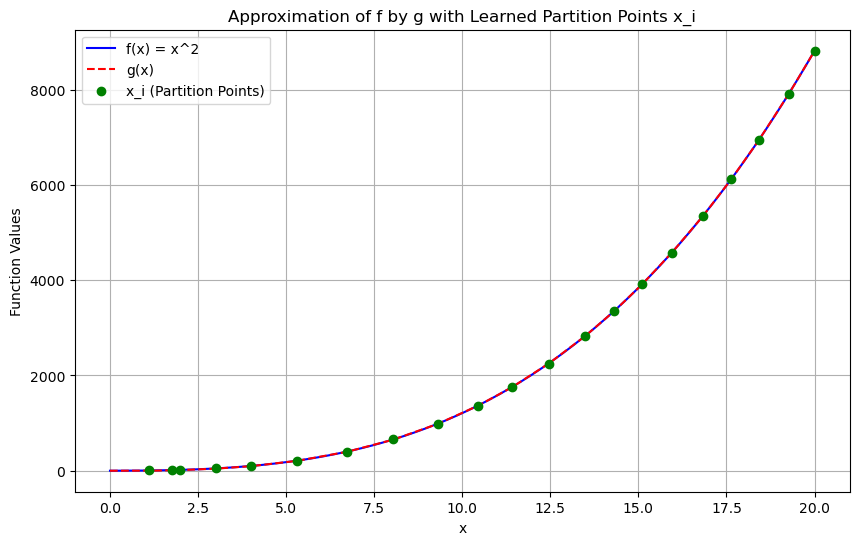

In [29]:
import matplotlib.pyplot as plt

# Post-training: visualize the results
x_plot = torch.linspace(a, b, 200)  # More points for a smoother plot
with torch.no_grad():  # No need to track gradients for plotting
    g_plot = model(x_plot)

# Convert tensors for plotting
x_plot = x_plot.numpy()
g_plot = g_plot.numpy()
x_i_plot = model.x_i.detach().numpy()

# Plotting the functions and x_i points
plt.figure(figsize=(10, 6))
plt.plot(x_plot, f(x_plot), label='f(x) = x^2', color='blue')
plt.plot(x_plot, g_plot, label='g(x)', color='red', linestyle='--')
plt.scatter(x_i_plot, f(torch.tensor(x_i_plot)), color='green', zorder=100, label='x_i (Partition Points)')

# Customize the plot
plt.title('Approximation of f by g with Learned Partition Points x_i')
plt.xlabel('x')
plt.ylabel('Function Values')
plt.legend()
plt.grid(True)
plt.show()